# Resume Screener — EDA

Exploratory analysis of the two datasets used in this project:

1. **Resume Dataset** (`snehaanbhawal/resume-dataset`) — resumes + category labels, used for classification.
2. **Recruitment Dataset** (`surendra365/recruitement-dataset`) — resume + job description + match label, used for JD-matching.

Run this notebook from the project root so relative paths resolve correctly.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_colwidth', 100)

In [2]:
## 1. Load Dataset 1 — Resume Categories

## Load Dataset 1 — Resume Categories

In [3]:
resume_df = pd.read_csv('../data/raw/Resume/Resume.csv')
print("Shape:", resume_df.shape)
resume_df.head(3)

Shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR Summary Dedicated Cu...,"<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS Summary Versatile media professional with ba...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=...",HR
2,33176873,"HR DIRECTOR Summary Over 20 years experience in recruiting, 15 plus years ...","<div class=""fontsize fontface vmargins hmargins linespacing pagesize"" id=""document""> <div class=...",HR


In [4]:
resume_df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

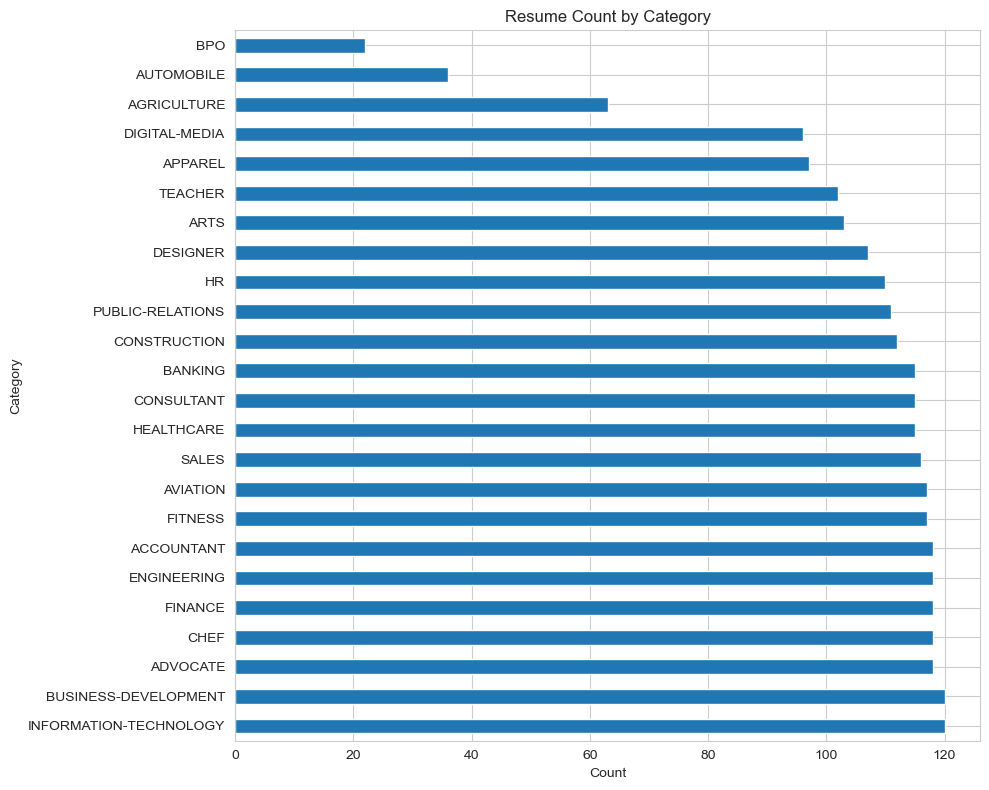

In [5]:
plt.figure(figsize=(10, 8))
resume_df['Category'].value_counts().plot(kind='barh')
plt.title('Resume Count by Category')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [6]:
resume_df['text_length'] = resume_df['Resume_str'].apply(lambda x: len(str(x).split()))
resume_df['text_length'].describe()

count    2484.000000
mean      811.325684
std       371.006906
min         0.000000
25%       651.000000
50%       757.000000
75%       933.000000
max      5190.000000
Name: text_length, dtype: float64

## 2. Load Dataset 2 — Recruitment (Resume + JD + Match)

In [7]:
recruitment_df = pd.read_csv('../data/recruitment_dataset/job_applicant_dataset.csv')
print("Shape:", recruitment_df.shape)
recruitment_df.head(3)

Shape: (10000, 9)


,Job Applicant Name,Age,Gender,Race,Ethnicity,Resume,Job Roles,Job Description,Best Match
0,Daisuke Mori,29,Male,Mongoloid/Asian,Vietnamese,"Proficient in Injury Prevention, Motivation, Nutrition, Health Coaching, Strength Training, with...",Fitness Coach,A Fitness Coach is responsible for helping clients achieve their fitness goals by designing and...,0
1,Taichi Shimizu,31,Male,Mongoloid/Asian,Filipino,"Proficient in Healthcare, Pharmacology, Medical Terminology, Patient Care, Surgical Skills, with...",Physician,"Diagnose and treat illnesses, prescribe medication, and provide ongoing patient care. Work in va...",0
2,Sarah Martin,46,Female,White/Caucasian,Dutch,"Proficient in Forecasting, Financial Modelling, Excel, Budgeting, Market Research, with senior-l...",Financial Analyst,"As a Financial Analyst, you will be responsible for evaluating financial data, preparing reports...",0


In [8]:
recruitment_df.isnull().sum()

Job Applicant Name    0
Age                   0
Gender                0
Race                  0
Ethnicity             0
Resume                0
Job Roles             0
Job Description       0
Best Match            0
dtype: int64

In [9]:
recruitment_df['Best Match'].value_counts(normalize=True) * 100

Best Match
0    51.5
1    48.5
Name: proportion, dtype: float64

In [10]:
recruitment_df['Job Roles'].value_counts().head(15)

Job Roles
Personal Trainer             226
Urban Planner                220
Biomedical Engineer          220
Construction Manager         215
Robotics Engineer            214
Mechanical Engineer          214
Operations Manager           209
Pilot                        209
Machine Learning Engineer    208
Web Developer                207
Financial Analyst            206
Systems Analyst              203
Environmental Scientist      203
Creative Director            203
Chef                         202
Name: count, dtype: int64

## 3. Sample resume + JD pair

In [11]:
sample = recruitment_df.iloc[0]
print("--- RESUME ---")
print(sample['Resume'][:500])
print("\n--- JOB DESCRIPTION ---")
print(sample['Job Description'][:500])
print("\n--- BEST MATCH LABEL ---")
print(sample['Best Match'])

--- RESUME ---
Proficient in Injury Prevention, Motivation, Nutrition, Health Coaching, Strength Training, with mid-level experience in the field. Holds a Bachelors degree. Holds certifications such as Certified Personal Trainer (CPT) by NASM. Skilled in delivering results and adapting to dynamic environments.

--- JOB DESCRIPTION ---
 A Fitness Coach is responsible for helping clients achieve their fitness goals by designing and leading group or individual fitness programs. You will provide instruction on exercises, proper form, and injury prevention techniques, encouraging clients to push their limits while maintaining a focus on their well-being. The role requires a passion for health and fitness, a strong understanding of exercise physiology, and the ability to motivate and inspire others. You will also monitor clients’ p

--- BEST MATCH LABEL ---
0


## 4. Test preprocessing pipeline on a sample

In [12]:
from preprocessing.text_cleaner import clean_text

raw = resume_df.iloc[0]['Resume_str']
cleaned = clean_text(raw)

print("RAW (first 300 chars):\n", raw[:300])
print("\nCLEANED (first 300 chars):\n", cleaned[:300])

RAW (first 300 chars):
          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

CLEANED (first 300 chars):
 hr administrator marketing associate hr administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfact


## 5. Test embeddings + match score on a sample pair

In [13]:
from models.matcher import compute_match

result = compute_match(sample['Resume'], sample['Job Description'])
print("Match score:", result['match_score'])
print("Matched keywords:", result['matched_keywords'])
print("Missing keywords:", result['missing_keywords'])

c:\Users\manas\miniconda3\envs\hf\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Match score: 58.93
Matched keywords: []
Missing keywords: ['fitness', 'coach', 'responsible', 'helping', 'client', 'achieve', 'goal', 'designing', 'leading', 'group', 'individual', 'program', 'provide', 'instruction', 'exercise']


## Findings / Notes

- Dataset 1 has 24 categories, some with far fewer samples (e.g. BPO) — worth using `class_weight='balanced'` when training the classifier.
- Dataset 2's `Best Match` label distribution should be checked for imbalance before treating it as a supervised target.
- Text cleaning strips emails/phone numbers/URLs, which keeps embeddings focused on actual skill/experience content.

In [14]:
%pip install sentence-transformers pdfplumber python-docx fastapi uvicorn streamlit

Note: you may need to restart the kernel to use updated packages.
